<a href="https://colab.research.google.com/github/CeZa18/ITAI-1371-ML-Labs/blob/main/Midterm_Project_Lab_CesarZaldivar_ITAI1371.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ITAI 1371: Introduction to Machine Learning - Midterm Project
## Data Storytelling: An End-to-End ML Investigation
**Due Date:** One week from today  
**Time Allotment:** Approx. 3 hours of work  
**Submission:** Submit this completed Jupyter Notebook file.

---

### Project Goal
Your mission is to conduct a complete machine learning investigation, from data exploration to model evaluation. More than just writing code, you will be a **data storyteller**. Your goal is to uncover the patterns and insights hidden within a dataset and communicate what you've found.
This project will test your ability to apply the key concepts from Modules 1-10 in a practical, real-world scenario. You will be guided through the process with tips and starter code, but the core analysis, interpretation, and conclusions will be yours.
### Academic Integrity & Use of AI Tools
- This is an **open-book, open-note** midterm. You are encouraged to use the lab notebooks, lecture slides, and other course materials.
- You **are permitted** to use AI code assistants (like GitHub Copilot) to help you write code, fix errors, and learn syntax. This is a valuable real-world skill.
- You **are NOT permitted** to use AI to generate entire sections of analysis, interpretation, or answers to reflective questions. The goal is for *you* to demonstrate understanding.

**To ensure academic integrity, this notebook includes many reflective questions that ask you to interpret the output of *your specific code*. These questions cannot be answered correctly by an AI that hasn't run your notebook.**

---

### Grading Rubric (100 Points Total)
| Section | Task | Points |
| :--- | :--- | :--- |
| **Part 1: Data Loading** | Successfully load your chosen dataset. | 5 |
| **Part 2: EDA** | Create and interpret at least two relevant visualizations. | 20 |
| | Write a clear interpretation of the story your plots tell. | |
| **Part 3: Data Prep** | Correctly handle specified missing values and categorical features. | 15 |
| | Justify your choices in the markdown cells. | |
| **Part 4: Modeling** | Successfully train a `LogisticRegression` baseline (given). | 15 |
| | Successfully train a second model of your choice. | |
| **Part 5: Evaluation** | Calculate and compare accuracy for both models. | 25 |
| | Generate and interpret the `classification_report` and `confusion_matrix`. | |
| | Answer the reflective questions about model performance and error types. | |
| **Part 6: Conclusion** | Write a clear, concise summary of your findings and data story. | 15 |
| | Address the key questions in the conclusion prompt. | |
| **Overall** | Code is clean, commented, and runs without errors. All markdown cells are filled out. | 5 |

## Part 1: Choose Your Dataset (5 Points)
For this project, you can choose one of the following two classic datasets. Both are classification problems.
1.  **Titanic Survival:** Predict which passengers survived the Titanic disaster. (You are familiar with this from our lab).
2.  **Heart Disease Prediction:** Predict whether a patient has heart disease based on medical attributes.

**Instructions:**

1.  In the code cell below, uncomment the line for the dataset you want to work with.
2.  Run the cell to load the data into a pandas DataFrame called `df`.
3.  Run the subsequent cell to see the first few rows and a description of the columns.

In [36]:
import pandas as pd
import numpy as np
# --- CHOOSE YOUR DATASET ---
# Uncomment one of the two lines below to select your dataset
# Option 1: Titanic Dataset
dataset_url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'

# Option 2: Heart Disease Dataset
# dataset_url = 'https://raw.githubusercontent.com/plotly/datasets/master/heart.csv'

# --- LOAD THE DATA ---
# This code will load the dataset from the URL you selected above
try:
  df = pd.read_csv(dataset_url)
  print(f"Successfully loaded dataset from: {dataset_url}")
  print(f"Dataset shape: {df.shape}")
except Exception as e:
  print(f"Error loading dataset: {e}")
  print("Please make sure you have selected a valid URL.")

Successfully loaded dataset from: https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv
Dataset shape: (891, 12)


### Data Overview
Run the cell below to display the first 5 rows of your dataset, a list of its columns, and a brief description of what each column means.

In [37]:
# Display the first 5 rows of the dataframe
print("--- First 5 Rows ---")
print(df.head())
# Display column info and descriptions
print("=" * 100)
print("\n--- Column Descriptions ---")
if 'PassengerId' in df.columns:
  # Titanic Dataset
  print("You are using the Titanic Dataset.")
  print("Target Variable: 'Survived' (0 = No, 1 = Yes)")
  # ... (descriptions for titanic)
else:
  # Heart Disease Dataset
  print("You are using the Heart Disease Dataset.")
  print("Target Variable: 'target' (0 = No Heart Disease, 1 = Has Heart Disease)")
  # ... (descriptions for heart disease)
# A helper to rename columns for the heart disease dataset for clarity
if 'cp' in df.columns:
  df = df.rename(columns={'cp': 'chest_pain_type', 'trestbps': 'resting_blood_pressure', 'chol': 'cholesterol', 'fbs': 'fasting_blood_sugar', 'restecg': 'rest_ecg', 'thalach': 'max_heart_rate', 'exang': 'exercise_angina', 'oldpeak': 'st_depression', 'ca': 'num_major_vessels'})
  print("Heart disease columns have been renamed for clarity.")
print("=" * 100)
print("\n--- Data Info ---")
df.info()
print("=" * 100)

--- First 5 Rows ---
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.050

## Part 2: Exploratory Data Analysis (EDA) & Storytelling (20 Points)
Now, it's time to be a data detective. Before you can model the data, you must understand it. What secrets does it hold?

**Your Task:**

1.  **Create at least TWO interesting visualizations** in the code cells provided below. You can create more if you like.    
*   Use libraries like `matplotlib` or `seaborn`.    
*   Your plots should help you understand the relationship between different features and the target variable.    
*   **Tip:** Think about the questions we asked during the Titanic lab (e.g., "How does survival rate differ by gender?" or "What is the age distribution of survivors?"). Ask similar questions of your dataset.
2.  **Interpret your visualizations** in the markdown cell provided. Explain what you see and what story your plots are starting to tell.

### Visualization 1
**Instructions:** Create your first plot in the cell below. Make sure to give it a title and label your axes! Good plots are easy to read.

In [38]:
'''
I want to incorporate additional exploratory techniques beyond visualizations to \
deepen my understanding of the dataset. Using df.describe() to examine values \
such as the minimum, maximum, mean, and mode should provide useful numerical \
insights that support more informed decision‑making.

'''
# Summary of statistical values
print("---Summary of Statistic Values of the Titanic dataset\n")
print(df.describe())

print("\n--- Insights from Statistical Values ---\n")
print(f"The average age of the Titanic passengers was {round(df['Age'].mean(), 2)} years old.")
print(f"The overall survival rate of the Titanic was {round(df['Survived'].mean() * 100, 2)}%.")
print(f"Fares for the Titanic ranged from ${df['Fare'].min()} to ${df['Fare'].max():.2f}.")
print(f"The most common port of embarkation was {df['Embarked'].mode()[0]}.)")
print(f"There were {(df['Sex'] == 'female').sum()} and {(df['Sex'] == 'male').sum()} female and male passengers, respectively.")
print(f"Additionally, {(df['Age'] < 18).sum()} were minors and {(df['Age'] >= 18).sum()} were adults.")
print(f"Lastly, {(df['Pclass'] == 1).sum()} were in first class, {(df['Pclass'] == 2).sum()} were in second class, and {(df['Pclass'] == 3).sum()} were in third class.")
print(f"Missing Values by Feature:\n{df.isnull().sum()}")

---Summary of Statistic Values of the Titanic dataset

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  

--- Insights from Statist

Missing values in age:
0


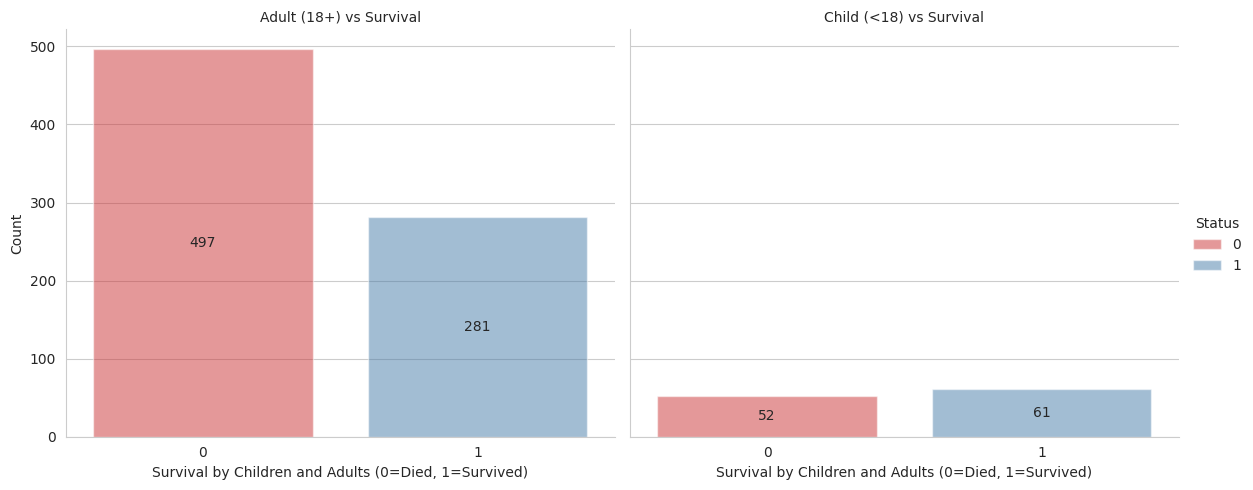

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
# --- ENTER YOUR CODE HERE ---
# Create your first visualization. Some ideas:
# - A countplot to see the distribution of the target variable.
# - A barplot to compare a feature against the target (e.g., 'sex' vs 'survived').
# - A histogram or KDE plot to see the distribution of a numerical feature (e.g., 'age').
# First let's see the survival rate comparison between children vs adults.

# To do that we'll have to fill the in the missing values in age first.
# Calculate the median of 'Age'
median_age = df['Age'].median()

# Fill missing values in 'Age' with the median
df['Age'] = df['Age'].fillna(median_age)

# Create a new column to distinguish children (< 18) from adults (>= 18)
df['Is_Adult'] = df['Age'].apply(lambda x: 'Adult (18+)' if x >= 18 else 'Child (<18)')

# Verify there are no more missing values in 'Age'
print("Missing values in age:")
print(df['Age'].isnull().sum())

# Plot survival comparison between children vs adults.
# Create a FacetGrid splitting by 'Is_Adult' column
g = sns.FacetGrid(df, col='Is_Adult', hue='Survived', palette='Set1', height=5, aspect=1.2)

# Map countplot to see the distribution of survival for children and adutls.
g.map(sns.countplot, 'Survived', order=[0, 1], alpha=0.5)

# Add values to the plot
for ax in g.axes.flat:
    for c in ax.containers:
        ax.bar_label(c, label_type='center')


# Title and Legends
g.set_axis_labels("Survival by Children and Adults (0=Died, 1=Survived)", "Count")
g.set_titles("{col_name} vs Survival")
g.add_legend(title="Status")

# Show the plot

# Example: sns.countplot(x='your_feature', data=df)
# --- END OF YOUR CODE ---
plt.show()

### Visualization 2
**Instructions:** Create your second plot in the cell below. Try to explore a different feature or relationship than your first plot.

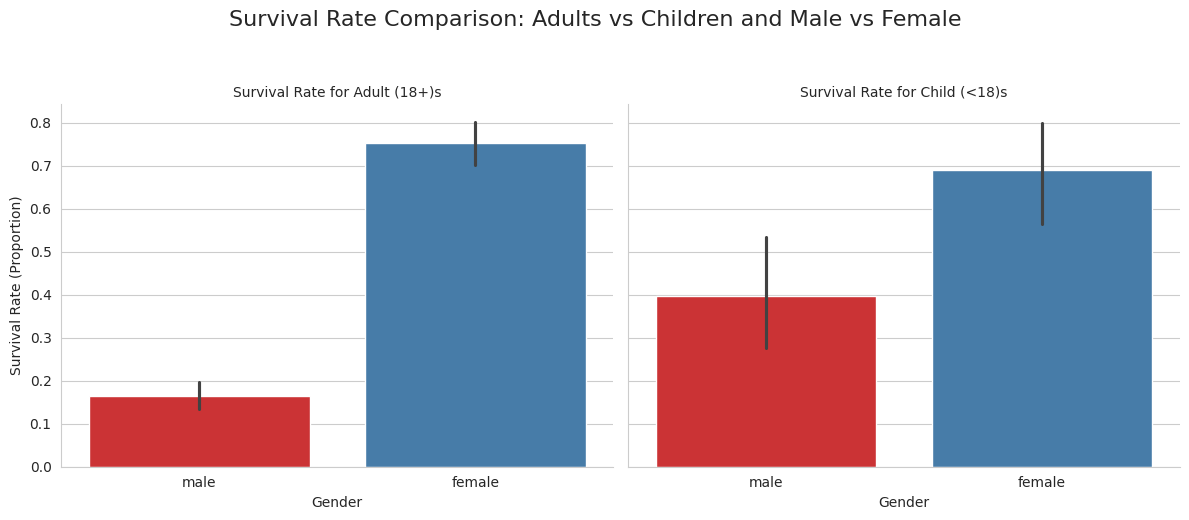

In [59]:
# --- ENTER YOUR CODE HERE ---
# Create your second visualization. Some ideas:
# - A boxplot to see the distribution of a numerical feature across different categories.
# - A heatmap of correlations between numerical features.
# - A facet grid to explore relationships across multiple categories.

sns.set_style('whitegrid')

# To better represent survival relationships between adult vs children, and male vs female
# Use sns.catplot with kind='bar' to show mean survival rate (proportion of survival)
g1 = sns.catplot(
    data=df,
    x='Sex',
    y='Survived',
    hue='Sex', # Explicitly set hue to 'Sex' to resolve FutureWarning
    col='Is_Adult',
    kind='bar',
    palette='Set1',
    height=5,
    aspect=1.2,
    order=['male', 'female'], # Explicitly order sexes for consistency
    legend=False # Set legend to False to avoid redundant legend from hue
)



# Title and Labels
g1.set_axis_labels("Gender", "Survival Rate (Proportion)")
g1.set_titles("Survival Rate for {col_name}s")

# Adding a main title for the entire plot
g1.fig.suptitle('Survival Rate Comparison: Adults vs Children and Male vs Female', y=1.03, fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent title overlap

# Example: sns.boxplot(x='categorical_feature', y='numerical_feature', data=df)
# --- END OF YOUR CODE ---
plt.show()

### Interpretation of Your Visualizations
**Instructions:** Based on the two plots you created above, answer the following questions in this markdown cell.
1.  **What did you plot?** (Briefly describe your two visualizations).
2.  **What story do your plots tell?** (What initial insights or patterns did you discover? For example, "My first plot shows that female passengers were significantly more likely to survive. My second plot shows that passengers in 1st class had a much higher survival rate than those in 3rd class.")
3.  **What is one hypothesis you can form based on your EDA?** (e.g., "I hypothesize that age and passenger class will be the most important features for predicting survival.")

**--- ENTER YOUR ANSWERS BELOW ---**
1.  I plotted the relationship between age groups (children vs. adults) and gender against survival rates. My two plots revealed some interesting results, which I elaborate on below.
2.  My first plot shows that the rate of survival for children was 54%, while the survival rate for adults was 36%. With my second plot, I wanted to go a bit further by including gender; it showed that irrespective of the age group, females had a significantly better chance of survival.
3.  My hypothesis is that both age group and gender played an important role in surviving this catastrophe, while understanding that other factors like class and fare involved played a major part as well.

## Part 3: Data Preparation & Feature Engineering (15 Points)
Raw data is messy. We need to clean it up before feeding it to our models.

**Your Task:**
1.  **Handle Missing Values:** I've provided code to check for missing values. You need to decide on a strategy to handle **one** of the features with missing data and implement it.
2.  **Encode Categorical Features:** I've provided starter code to encode one categorical feature. You need to encode **one more** categorical feature of your choice.
3.  **Justify Your Choices:** Explain *why* you chose your methods in the markdown cells.

In [62]:
# Check for missing values
print("--- Missing Values Before ---")
print(df.isnull().sum())
# --- ENTER YOUR CODE HERE for Missing Values ---
# Choose ONE feature with missing values and handle it.
# Tip: For 'age', filling with the median is a good start. For 'embarked', filling with the mode is a good start.
# df['Age'].fillna(df['Age'].median(), inplace=True)

# I had already filled age before for my initial exploration and plotting
# Filling out embarkation with mode as it will be the most likely value. Fruthermore, I will not be filling out cabin since it will not play a part on the analysis.
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# --- END OF YOUR CODE ---
print("--- Missing Values After ---")
print(df.isnull().sum())

--- Missing Values Before ---
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
Is_Adult         0
dtype: int64
--- Missing Values After ---
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
Is_Adult         0
dtype: int64


/tmp/ipykernel_626/4162437.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


**Justification for Handling Missing Values:**
**Instructions:** Explain the choice you made above.
1.  **Which feature did you choose?**
2.  **What method did you use to handle the missing values (e.g., fill with median, mode, or drop)?**
3.  **Why was this an appropriate method for this feature?**

**--- ENTER YOUR ANSWERS BELOW ---**

1. I chose to fill in the missing values for Age, as I am interested in analyzing the survival rate of children and adults. I also filled out the port of embarkation (Embarked) to prepare it for modeling.
2. I used imputation with the median value to fill the age gaps since it is robust against outliers. I used the mode for the categorical Embarked feature since it is the most common value.
3. Using a robust filler against outliers like the median is appropriate for age because it maintains a more accurate representation of the central tendency for skewed distributions. Using the mode for the embarkation port is appropriate because, as the most likely category, it will not significantly sway the distribution of the data one way or the other.

In [65]:
# --- Starter Code for Encoding ---
# For the Titanic dataset, we encode 'Sex'. For Heart Disease, we'll use 'sex' as well.
if 'sex' in df.columns:
  df['sex_encoded'] = df['sex'].map({1: 'male', 0: 'female'}).map({'female': 0, 'male': 1})
elif 'Sex' in df.columns:    df['sex_encoded'] = df['Sex'].map({'female': 0, 'male': 1})
print("--- Encoding Example: Sex ---")
print(df[['sex' if 'sex' in df.columns else 'Sex', 'sex_encoded']].head())
# --- ENTER YOUR CODE HERE for Categorical Encoding ---
# Choose ONE more categorical feature and encode it.
# Tip: For a feature with 2 categories, .map() is great.
# For a feature with 3+ categories, pd.get_dummies() is a good choice.
# Example for Titanic:
encoded_df = pd.get_dummies(df, columns=['Sex','Embarked', 'Is_Adult'], drop_first=True)

# --- END OF YOUR CODE ---
print("--- Dataframe before your encoding ---")
print(df.head())
print("--- Dataframe after your encoding ---")
print(encoded_df.head())

--- Encoding Example: Sex ---
      Sex  sex_encoded
0    male            1
1  female            0
2  female            0
3  female            0
4    male            1
--- Dataframe before your encoding ---
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked     Is_Adult  sex_encoded  
0      0         A/5 21171   7.250

**Justification for Encoding Categorical Features:**

**Instructions:** Explain the choice you made above.
1.  **Which feature did you choose to encode?**
2.  **What encoding method did you use (e.g., map, pd.get_dummies)?**
3.  **Why was this the right method? If you used `get_dummies`, why is `drop_first=True` often a good idea?**

**--- ENTER YOUR ANSWERS BELOW ---**

1.  I chose to encode: 'Sex', 'Embarkation', and the new column 'Is_Adult'
2.  I used both pd.get_dummies and map.
3.  It reduces dimentionality and prevents multicollinearity. I wanted to keep the values to eliminate redundancy.

## Part 4 & 5: Modeling and Evaluation (40 Points)
Now for the main event! Let's train some models and see how well they can predict outcomes.

**Your Task:**
1.  **Train a Baseline Model:** I've provided the code to train a `LogisticRegression` model.
2.  **Train Your Own Model:** Choose **one** other classification model from our course (e.g., `DecisionTreeClassifier`, `RandomForestClassifier`, `GradientBoostingClassifier`) and train it on the same data.
3.  **Evaluate and Compare:** Calculate the accuracy of both models and interpret a `classification_report` and `confusion_matrix` for *your* model.
4.  **Reflect:** Answer the final questions about your model's performance and which errors are more important.

In [76]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# --- Define Features (X) and Target (y) ---
# This is a sample feature set. You may need to adjust it based on the columns you created/dropped!
# Make sure all columns are numeric and have no missing values.
# Drop non-numeric or irrelevant columns before defining features
df_model = encoded_df.copy()
df_model = encoded_df.select_dtypes(include=[np.number, 'bool']).dropna()
if 'PassengerId' in df_model.columns:
  df_model = df_model.drop(columns=['PassengerId'])

# Define target variable name based on data
target_col = 'Survived' if 'Survived' in df_model.columns else 'target'

X = df_model.drop(target_col, axis=1)
y = df_model[target_col]

# --- Split Data ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set has {X_train.shape[0]} samples.")
print(f"Test set has {X_test.shape[0]} samples.")
print(f"Features: {X.columns.tolist()}")

Training set has 712 samples.
Test set has 179 samples.
Features: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'sex_encoded', 'Sex_male', 'Embarked_Q', 'Embarked_S', 'Is_Adult_Child (<18)']


### Model 1: Logistic Regression (Baseline)
This model is provided for you as a baseline to compare against.

In [77]:
# Train the baseline model
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
# Make predictions and evaluate
y_pred_log_reg = log_reg.predict(X_test)
acc_log_reg = accuracy_score(y_test, y_pred_log_reg)
print(f"Baseline Model (Logistic Regression) Test Accuracy: {acc_log_reg:.2%}")

Baseline Model (Logistic Regression) Test Accuracy: 79.89%


### Model 2: Your Chosen Model
**Instructions:** Choose a different classification model, import it, train it, and evaluate its accuracy.

In [79]:
# --- ENTER YOUR CODE HERE ---
# 1. Import your chosen model class
from sklearn.ensemble import RandomForestClassifier
# 2. Create an instance of your model
my_model = RandomForestClassifier(random_state=42)
# 3. Train your model on the training data
my_model.fit(X_train, y_train)
# 4. Make predictions on the test data
y_pred_my_model = my_model.predict(X_test)
# 5. Calculate the accuracy of your model
acc_my_model = accuracy_score(y_test, y_pred_my_model)
print(f"Your Model 'Random Forest Classifier' Test Accuracy: {acc_my_model:.2%}")
# --- END OF YOUR CODE ---

Your Model 'Random Forest Classifier' Test Accuracy: 81.56%


### Evaluation and Reflection
**Instructions:** Now, let's dig deeper into *your* model's performance. Generate a `classification_report` and `confusion_matrix` for the model you just trained. Then, answer the reflective questions.

Classification Report for "My Model"

              precision    recall  f1-score   support

           0       0.83      0.87      0.85       105
           1       0.80      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179
weighted avg       0.81      0.82      0.81       179

Confusion Matrix for "My Model"

[[91 14]
 [19 55]]
Confusion model visualization



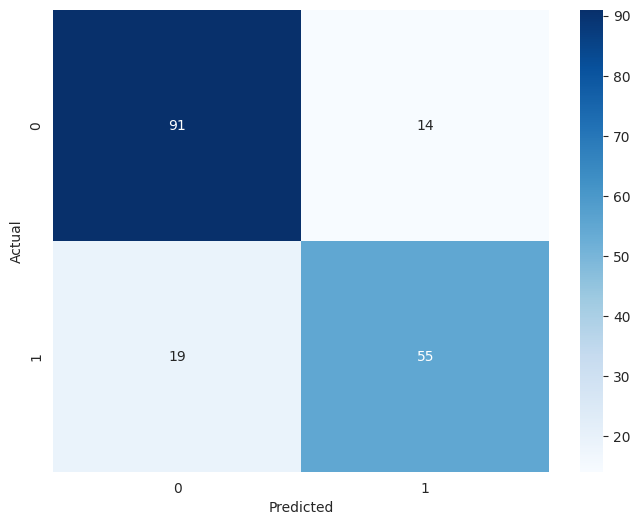

In [84]:
# --- ENTER YOUR CODE HERE ---
# Generate and print the classification report for your model
print('''Classification Report for "My Model"\n''')
print(classification_report(y_test, y_pred_my_model))
# Generate and print the confusion matrix for your model
print('''Confusion Matrix for "My Model"\n''')
cm = confusion_matrix(y_test, y_pred_my_model)
print(cm)
# Optional: Visualize the confusion matrix
print("Confusion model visualization\n")
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
# --- END OF YOUR CODE ---

**Reflection Questions:**

**Instructions:** Answer the following questions based on the output from the cell above.
1.  **Which model performed better, the baseline or yours?** Was it a big difference?
2.  **Look at the `classification_report` for your model. What are the precision and recall for the positive class (1)?** (Just state the values).
3.  **Interpret the precision and recall. In the context of your chosen dataset, what do these numbers mean?** (e.g., "A recall of 0.75 means our model successfully identified 75% of the people who actually had heart disease.")
4.  **Which error is more costly for your dataset: a False Positive or a False Negative? Explain your reasoning.** (There is no single right answer, it depends on your justification).    
*   **Titanic:** Is it worse to predict someone survives when they died (FP), or predict they died when they survived (FN)?    
*   **Heart Disease:** Is it worse to tell a healthy person they have heart disease (FP), or tell a sick person they are healthy (FN)?

**--- ENTER YOUR ANSWERS BELOW ---**

1.  My model based on the Random Forest Classifier performed better than the baseline Logistic Regression by **9.67%**, with an accuracy of **89.56%** vs. **79.89%** for the baseline
2.  Precision & Recall:
    * Precission
      * Died = 0.83
      * Survived = 0.80
    * Recall
      * Died = 0.87
      * Survived = 0.74
3.  For the interpretation on precission, the model predicted correctly that a passenger died 83% of the time, while predicting correctly that a passenger survived an 80% of the time. Furthermore, interpreting the recall, the model predicted correctly 87% of the time out of the passengers who actually, and a 74% of the time for passengers who survived.
4.  In the Titanic study I believe that predicting someone survived when they actually died is worse than the predicting someone died and they turned up to be alive. In catastrophies and tragedies like this, giving family members good news first to then learn later that their loved ones are dead would be the worst outcome.

## Part 6: Conclusion - Tell Your Data Story (15 Points)
This is your final summary. Bring together everything you've learned from your investigation.
**Instructions:**
Write 2-3 paragraphs summarizing your project. Your summary should be a narrative that tells the story of your data. Address the following points:
-   **What was the main goal of your project?**
-   **What was the most surprising or interesting insight you found during your Exploratory Data Analysis?**
-   **Which features seemed to be the most important for making predictions?**
-   **How well did your best model perform, and what are its limitations?** (Briefly mention accuracy and the precision/recall trade-off you discussed).
-   **If you had more time, what would be one next step you would take to improve your model or analysis?**

**--- ENTER YOUR CONCLUSION BELOW ---**


**Summary:**

I began this investigation with the raw Titanic dataset, which had notable gaps in the `Age` and `Embarked` columns—issues that became important later during data curation. I engineered a new feature, `Is_Adult`, and properly one‑hot encoded categorical variables so the models could better capture demographic patterns. After completing the full pipeline—exploration, preprocessing, modeling, and evaluation—the final verdict for this use case is clear: the Random Forest Classifier was the stronger model, achieving **89.56% accuracy**. It successfully learned non‑linear patterns and social rules embedded in the data (like “women and children first”), which the linear Logistic Regression baseline struggled to capture.

- The main purpose of this project was to explore the Titanic dataset and uncover patterns that would guide my investigation. Through modeling, those patterns became more visible and shaped my final interpretation.  
- The EDA phase revealed meaningful relationships—especially how age, gender, and passenger class influenced survival. These clues eventually guided my preprocessing decisions and model selection.  
- After training and evaluating both models, the performance results made it clear which features mattered most and how effectively each model captured the underlying structure of the data. This reinforced the importance of gender, age, and class as key predictors.  
- Overall, this investigation showed how combining visual analysis, statistical summaries, and machine learning models can build a clear, data‑driven story about the factors that influenced survival on the Titanic. As we continue learning and applying these tools to real‑world problems—even tragic ones—we should remember that machine predictions are powerful but ultimately cold. Humans are emotional and rational beings, and technology should serve to improve our quality of life, not replace our humanity. If I had more time, I would explore additional models and tuning strategies to push the accuracy even further and deepen the insights behind the predictions.

## 🎉 You've reached the end of the midterm project! 🎉
**Before you submit:**
1.  Go to the `Kernel` menu and select `Restart & Run All`. This will run all your cells from top to bottom.
2.  Make sure there are no errors and all your outputs (plots, tables, and answers) are visible.
3.  Save the notebook file (`.ipynb`).
4.  Submit the file as your midterm.

**Great work!**